###Gerando Dados Sintéticos

In [23]:
dados = []
labels = []

# Dados de pacientes normais
for _ in range(500):

    serie = np.random.normal(
        80,
        10,
        20
    )

    dados.append(serie)

    labels.append(0)

# Dados de Taquicardia
for _ in range(500):

    serie = np.random.normal(
        110,
        15,
        20
    )

    # adicionando picos
    pico = random.randint(5, 15)

    serie[pico:pico+3] += 20

    dados.append(serie)

    labels.append(1)

##Regressão logística

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

modelo = LogisticRegression()

modelo.fit(X_train, y_train)

pred = modelo.predict(X_test)

acc = accuracy_score(y_test, pred)

print("Acurácia:", acc)

Acurácia: 1.0


##LIF

In [25]:
class LIFNeuron:

    def __init__(self,
                 threshold=25,
                 leak=0.85):

        self.threshold = threshold
        self.leak = leak

    def predict(self, serie):

        potencial = 0

        spikes = 0

        media = np.mean(serie)

        for valor in serie:

            # diferença em relação à média
            entrada = valor - media

            potencial = (
                potencial * self.leak
                + entrada
            )

            if potencial >= self.threshold:

                spikes += 1

                potencial = 0

        # classificação
        if spikes >= 2 or media > 100:
            return 1

        return 0

In [26]:
lif = LIFNeuron()

predicoes = []

for serie in X_test:

    predicoes.append(
        lif.predict(serie)
    )

acc_lif = accuracy_score(
    y_test,
    predicoes
)

print("Acurácia LIF:", acc_lif)

Acurácia LIF: 0.985


##Comparação

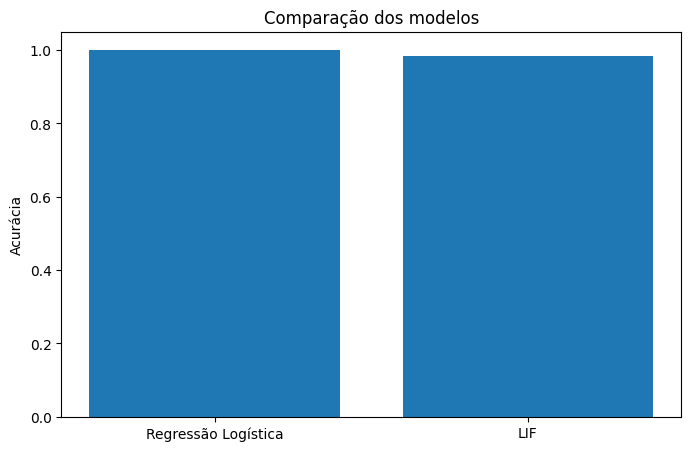

In [27]:
import matplotlib.pyplot as plt

modelos = [
    "Regressão Logística",
    "LIF"
]

acuracias = [
    acc,
    acc_lif
]

plt.figure(figsize=(8,5))

plt.bar(modelos, acuracias)

plt.ylabel("Acurácia")

plt.title("Comparação dos modelos")

plt.show()

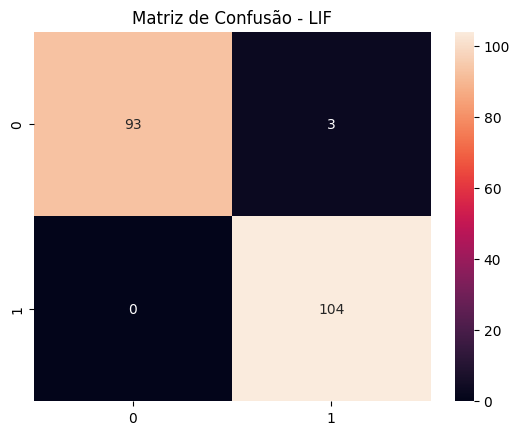

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    predicoes
)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.title("Matriz de Confusão - LIF")

plt.show()